# STalign parity: `merfish-visium-alignment-with-point-annotator.ipynb`

Executed one-to-one replay of [the pinned upstream notebook](https://github.com/JEFworks-Lab/STalign/blob/b2068edc98974efa54537eca194736e177bbe11d/docs/notebooks/merfish-visium-alignment-with-point-annotator.ipynb).

Status: `compared`. 


In [1]:
# per-variable relative L2: upstream STalign vs the squidpy JAX port


{
  "A relative L2": 1.0971644908114785e-06,
  "AI relative L2": 0.0,
  "L relative L2": 0.0,
  "V relative L2": 0.0,
  "Vnorm relative L2": 0.0,
  "WM relative L2": 9.558911886410433e-06,
  "affine relative L2": 0.0,
  "df3 relative L2": 2.6963079951154918e-05,
  "extentI relative L2": 0.0,
  "extentJ relative L2": 0.0,
  "levels relative L2": 0.0,
  "phiI relative L2": 0.000536424408597168,
  "phii relative L2": 3.005417627492909e-05,
  "phiipointsI relative L2": 3.426806588402625e-05,
  "pointsI relative L2": 0.0,
  "pointsIaffine relative L2": 0.0,
  "pointsJ relative L2": 0.0,
  "squidpy vs upstream published relative L2": 2.6085438380592618e-05,
  "testM relative L2": 0.005525168962776661,
  "tpointsI relative L2": 2.6963079951154918e-05,
  "trans_offset_0 relative L2": 0.0,
  "trans_offset_1 relative L2": 0.0,
  "upstream vs upstream published relative L2": 1.6686839793893895e-06,
  "v relative L2": 3.882913974238437e-05,
  "xI_LDDMM relative L2": 2.9979575198642713e-05,
  "xIaf

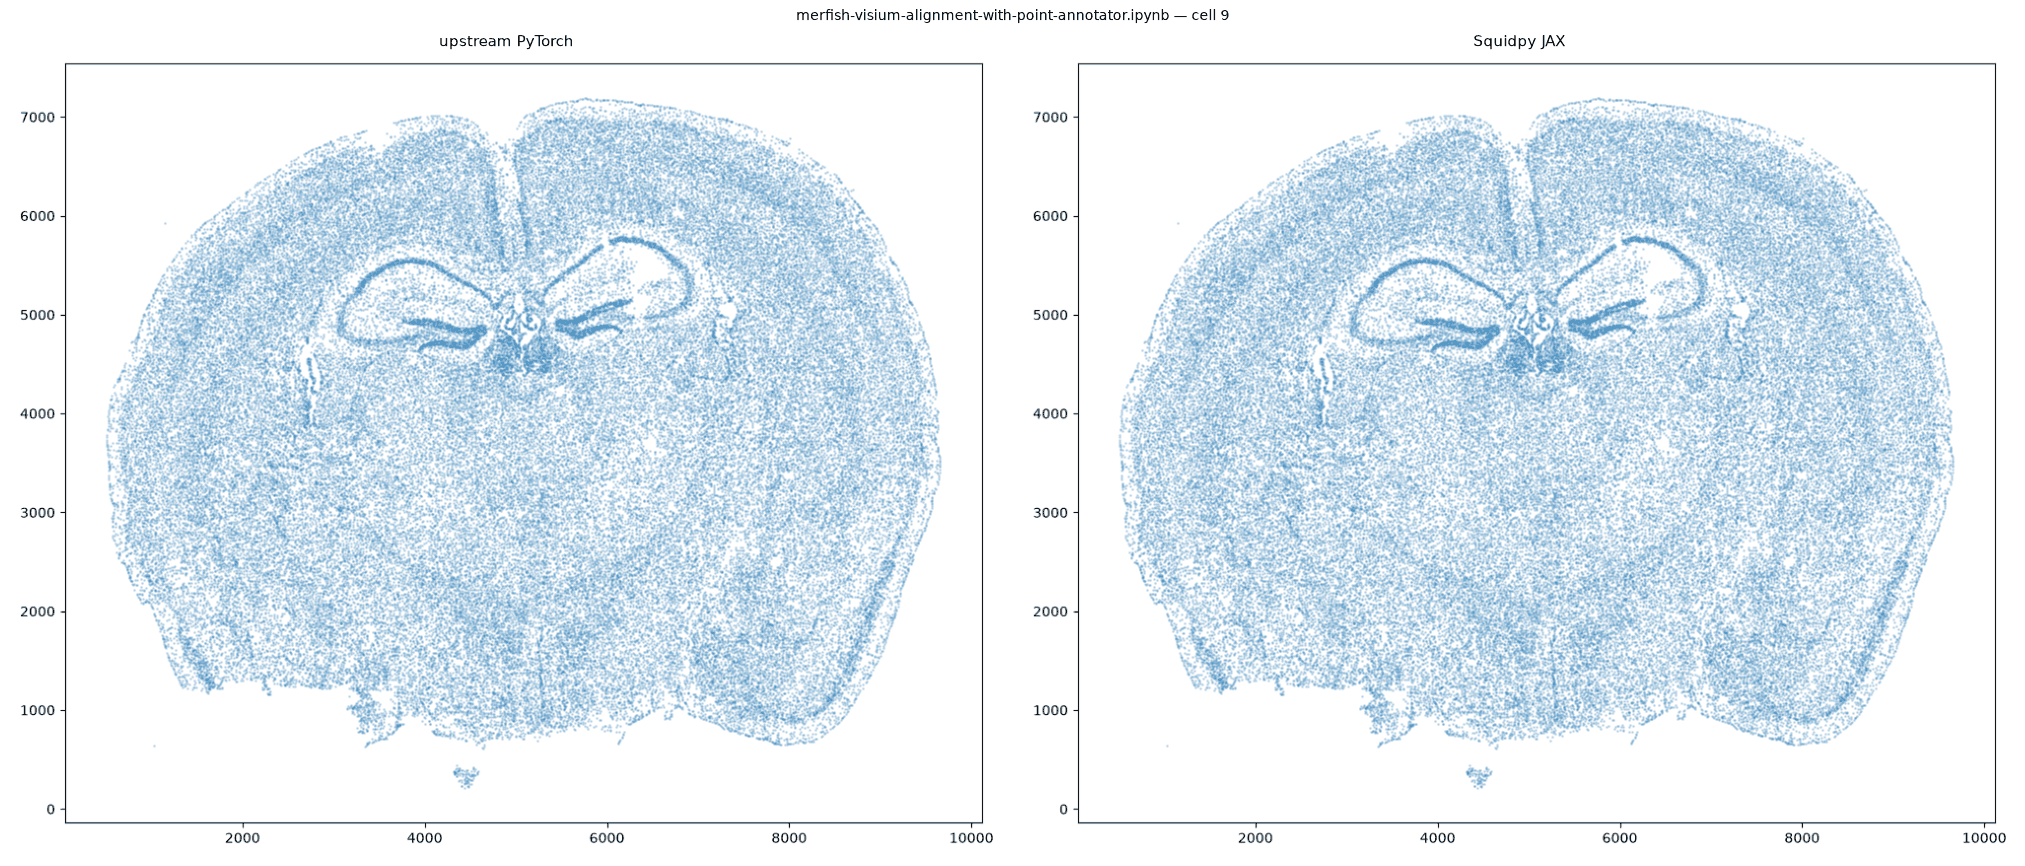

In [2]:
# get cell centroid coordinates
xI = np.array(df1['center_x'])
yI = np.array(df1['center_y'])

# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2)
#ax.set_aspect('equal', 'box')

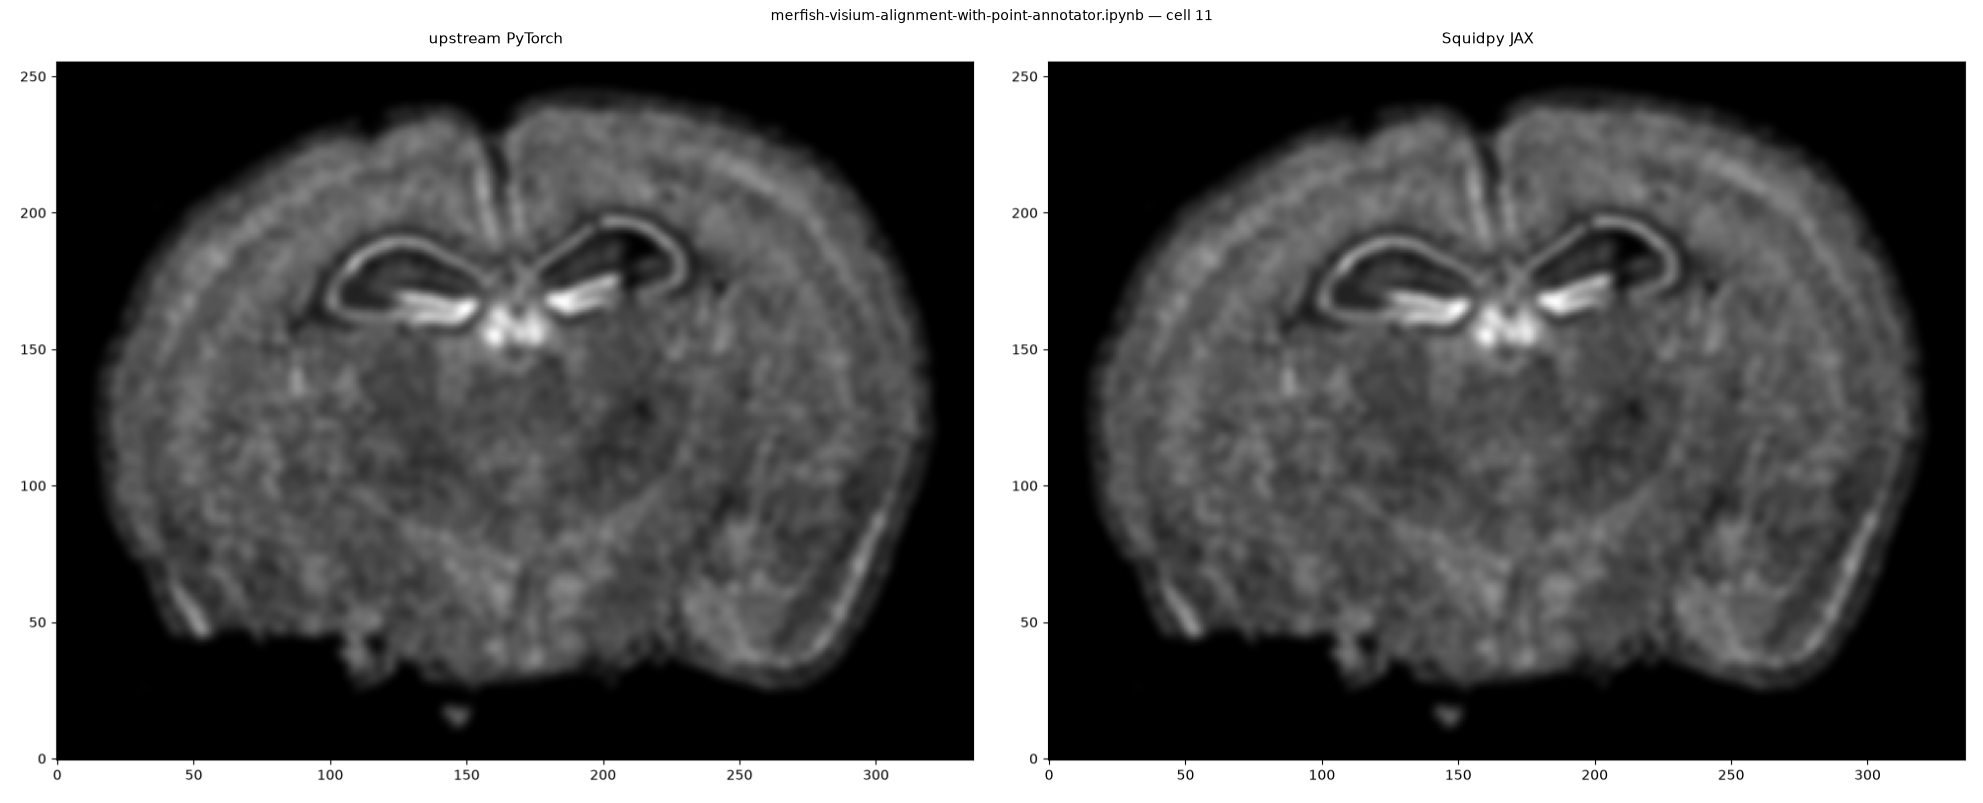

In [3]:
# rasterize at 30um resolution (assuming positions are in um units) and plot
XI,YI,I,fig = STalign.rasterize(xI, yI, dx=30)

ax = fig.axes[0]
ax.invert_yaxis()

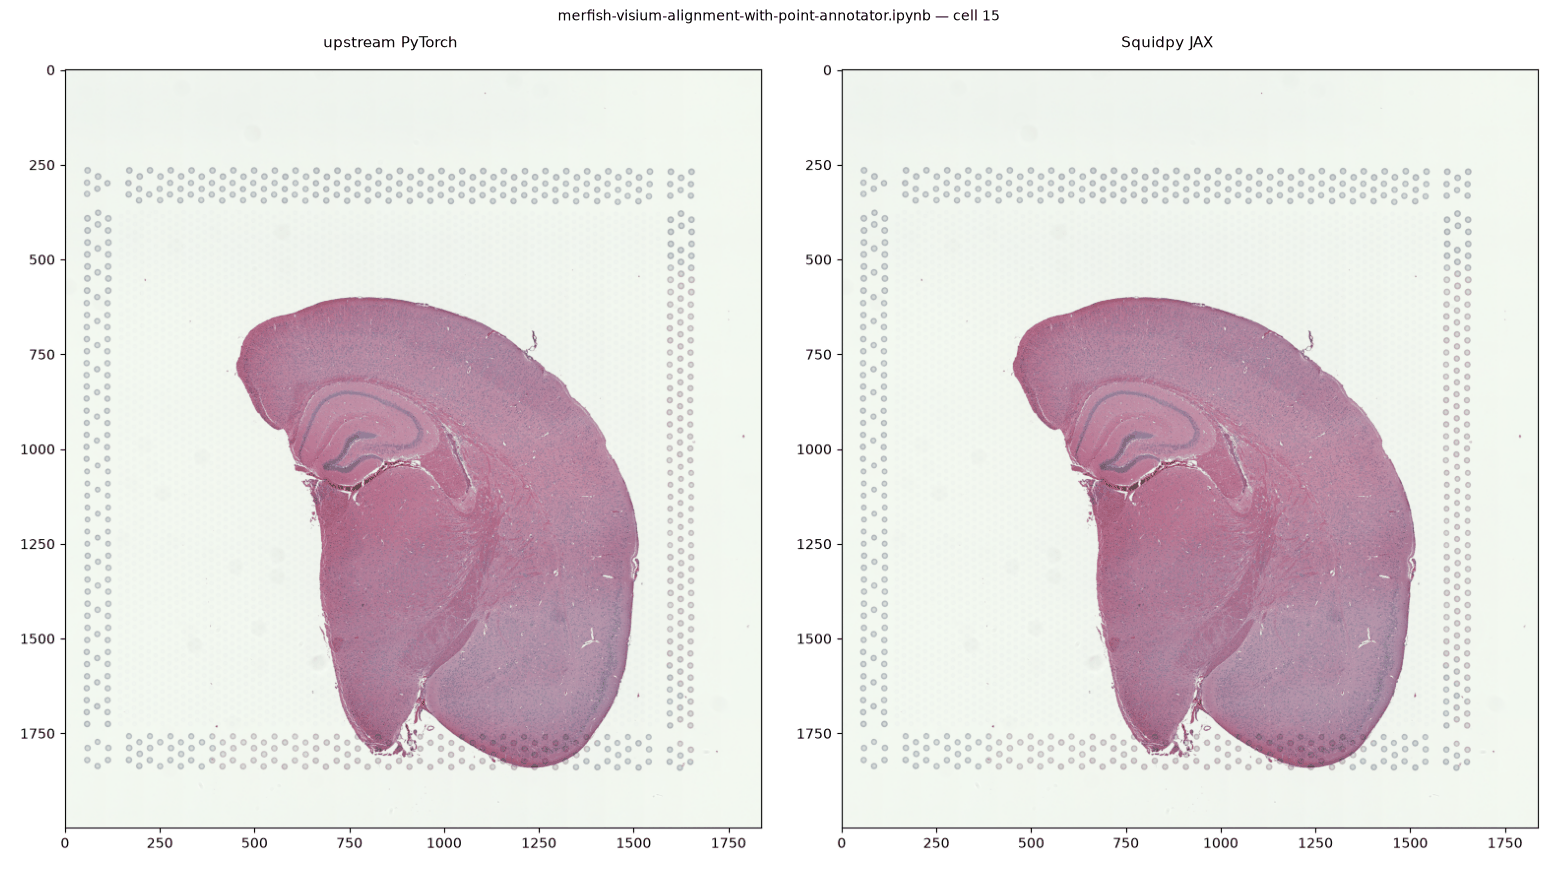

In [4]:
image_file = '../visium_data/tissue_hires_image.png'
V = plt.imread(image_file)

# plot
fig,ax = plt.subplots()
ax.imshow(V)

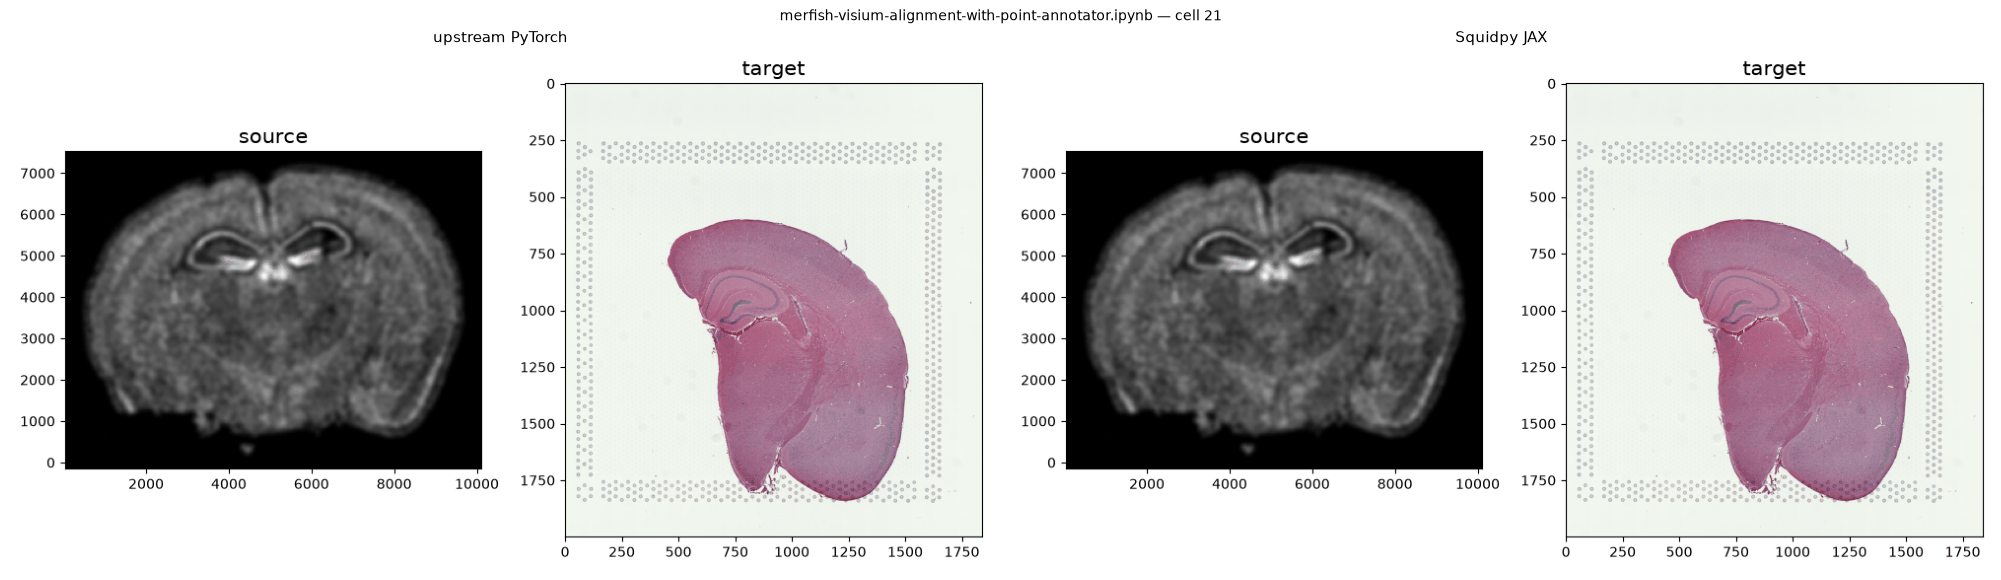

In [5]:
# plot

# get extent of images
extentJ = STalign.extent_from_x((YJ,XJ))
extentI = STalign.extent_from_x((YI,XI))

fig,ax = plt.subplots(1,2)
ax[0].imshow((I.transpose(1,2,0).squeeze()), extent=extentI) 
ax[0].invert_yaxis()
ax[0].set_title('source', fontsize=15)
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ)
ax[1].set_title('target', fontsize=15)

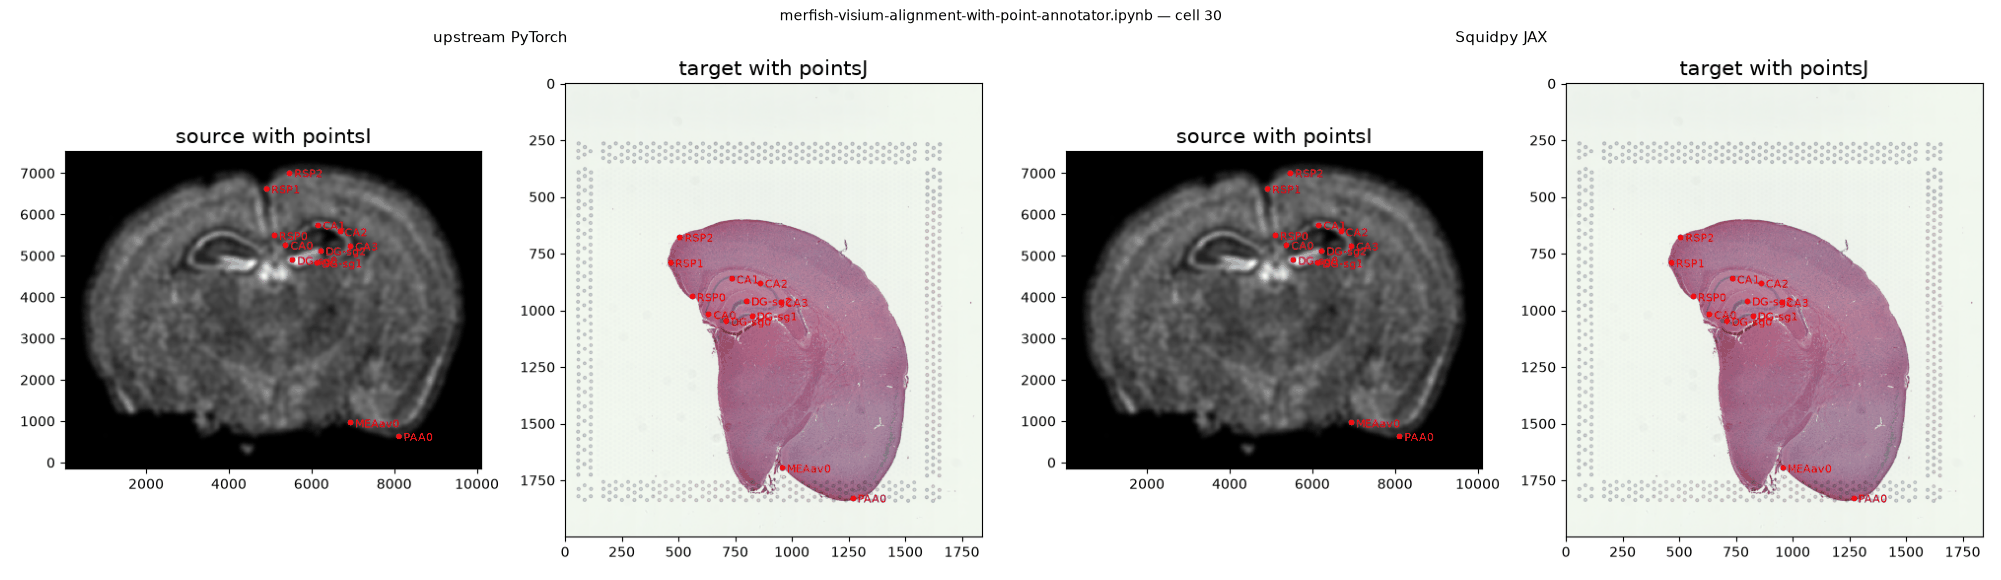

In [6]:
# plot

fig,ax = plt.subplots(1,2)
ax[0].imshow((I.transpose(1,2,0).squeeze()), extent=extentI) 
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ)

trans_offset_0 = mtransforms.offset_copy(ax[0].transData, fig=fig,
                                       x=0.05, y=-0.05, units='inches')
trans_offset_1 = mtransforms.offset_copy(ax[1].transData, fig=fig,
                                       x=0.05, y=-0.05, units='inches')

ax[0].scatter(pointsI[:,1],pointsI[:,0], c='red', s=10)
ax[1].scatter(pointsJ[:,1],pointsJ[:,0], c='red', s=10)
    
for i in pointsIlist.keys():
    for j in range(len(pointsIlist[i])):
        ax[0].text(pointsIlist[i][j][0], pointsIlist[i][j][1],f'{i}{j}', c='red', transform=trans_offset_0, fontsize= 8)
for i in pointsJlist.keys():
    for j in range(len(pointsJlist[i])):
        ax[1].text(pointsJlist[i][j][0], pointsJlist[i][j][1],f'{i}{j}', c='red', transform=trans_offset_1, fontsize= 8)
        
ax[0].set_title('source with pointsI', fontsize=15)
ax[1].set_title('target with pointsJ', fontsize=15)

# invert only rasterized image
ax[0].invert_yaxis()

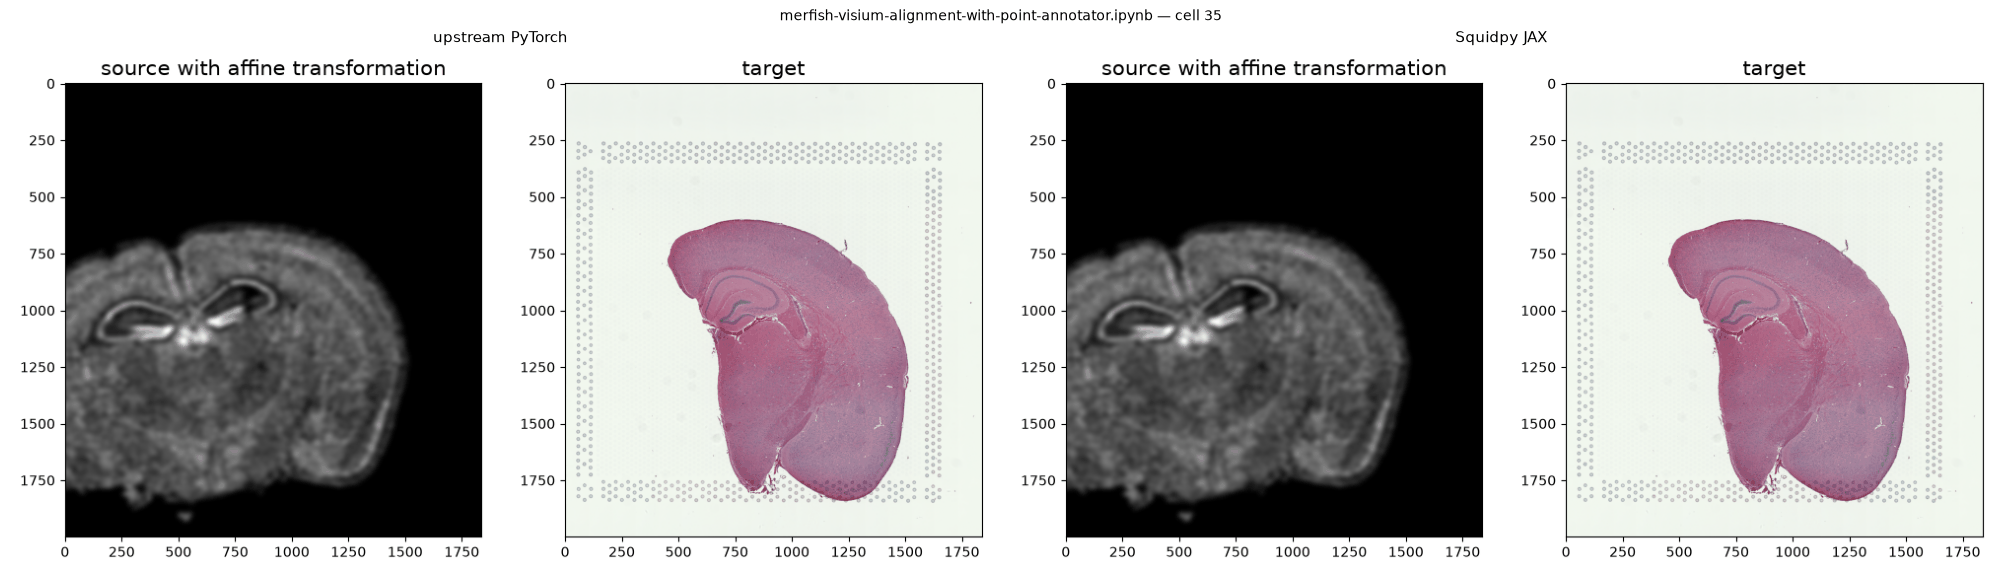

In [7]:
# compute initial affine transformation from points
AI= STalign.transform_image_source_with_A(A, [YI,XI], I, [YJ,XJ])

#switch tensor from cuda to cpu for plotting with numpy
if AI.is_cuda:
    AI = AI.cpu()

fig,ax = plt.subplots(1,2)

ax[0].imshow((AI.permute(1,2,0).squeeze()), extent=extentJ) 
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ) 

ax[0].set_title('source with affine transformation', fontsize=15)
ax[1].set_title('target', fontsize=15)

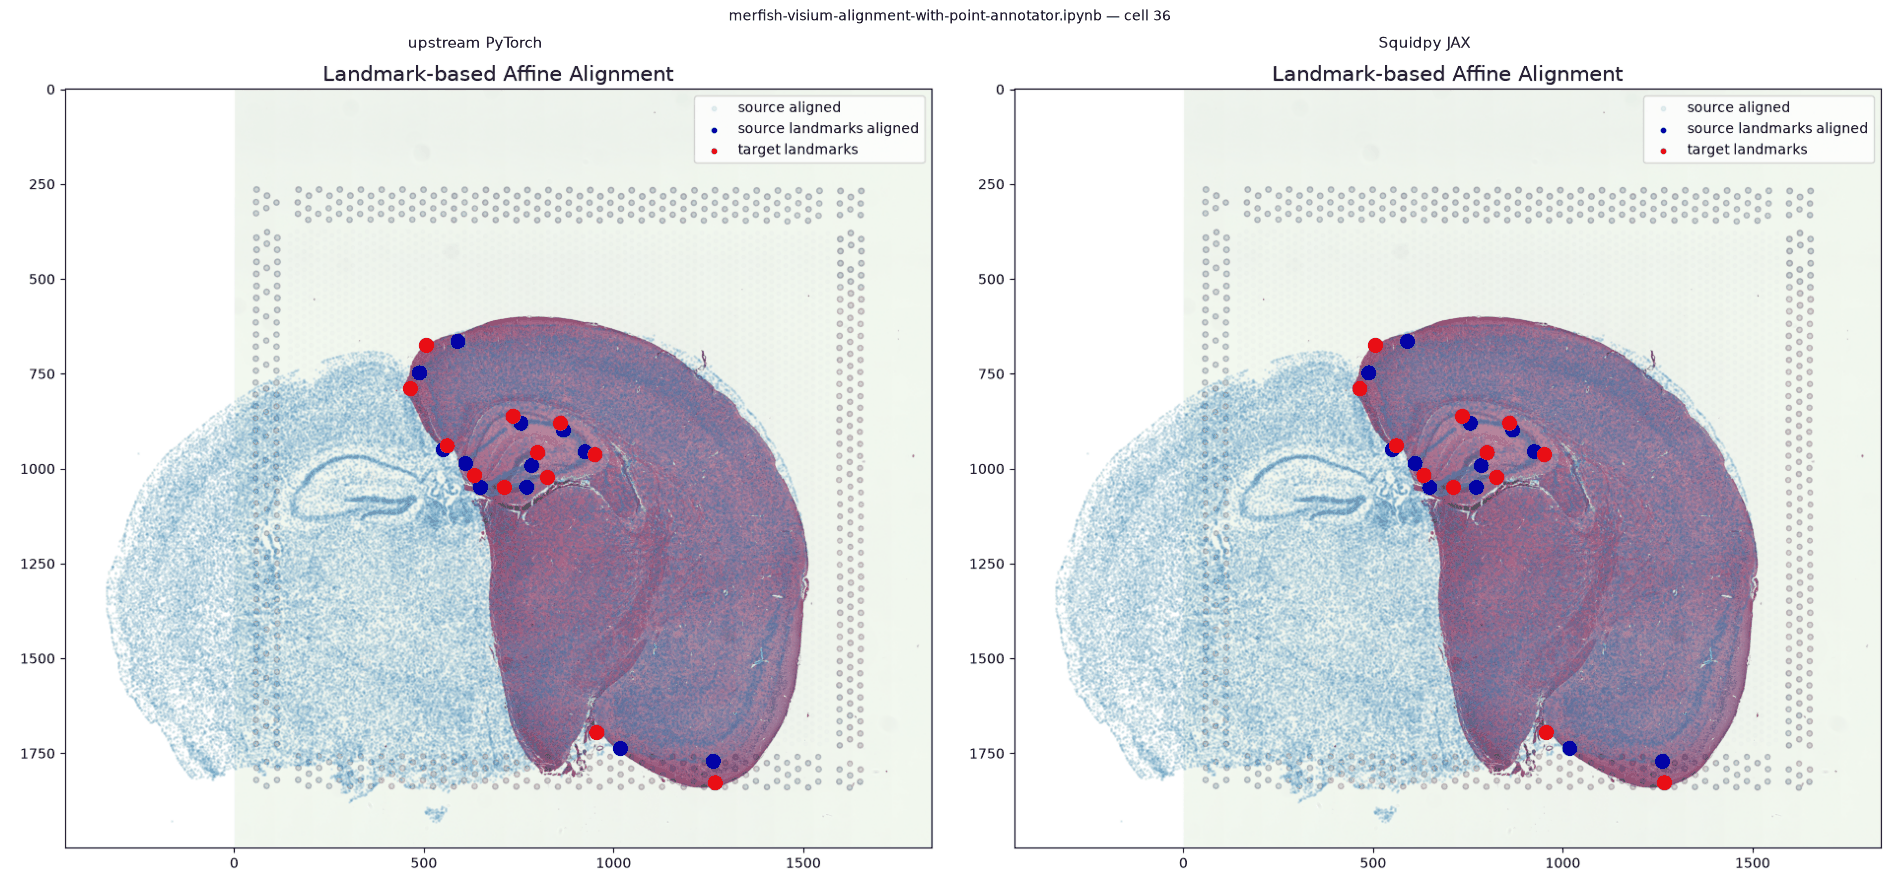

In [8]:
#apply A to sources points in row, column (y,x) orientation
affine = np.matmul(np.array(A.cpu()),np.array([yI, xI, np.ones(len(xI))]))

xIaffine = affine[1,:] 
yIaffine = affine[0,:]


#apply A to sources landmark points in row, column (y,x) orientation
ypointsI = pointsI[:,0]
xpointsI = pointsI[:,1]
affine = np.matmul(np.array(A.cpu()),np.array([ypointsI, xpointsI, np.ones(len(ypointsI))]))

xpointsIaffine = affine[1,:] 
ypointsIaffine = affine[0,:]
pointsIaffine = np.column_stack((ypointsIaffine,xpointsIaffine))


# plot results
fig,ax = plt.subplots()

ax.imshow((J).transpose(1,2,0),extent=extentJ)

ax.scatter(xIaffine,yIaffine,s=1,alpha=0.1, label = 'source aligned')
ax.scatter(pointsIaffine[:,1],pointsIaffine[:,0],c="blue", label='source landmarks aligned', s=100)
    
ax.scatter(pointsJ[:,1],pointsJ[:,0], c='red', label='target landmarks', s=100)
ax.set_aspect('equal')

lgnd = plt.legend(loc="upper right", scatterpoints=1, fontsize=10)
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])
    
ax.set_title('Landmark-based Affine Alignment', fontsize=15)

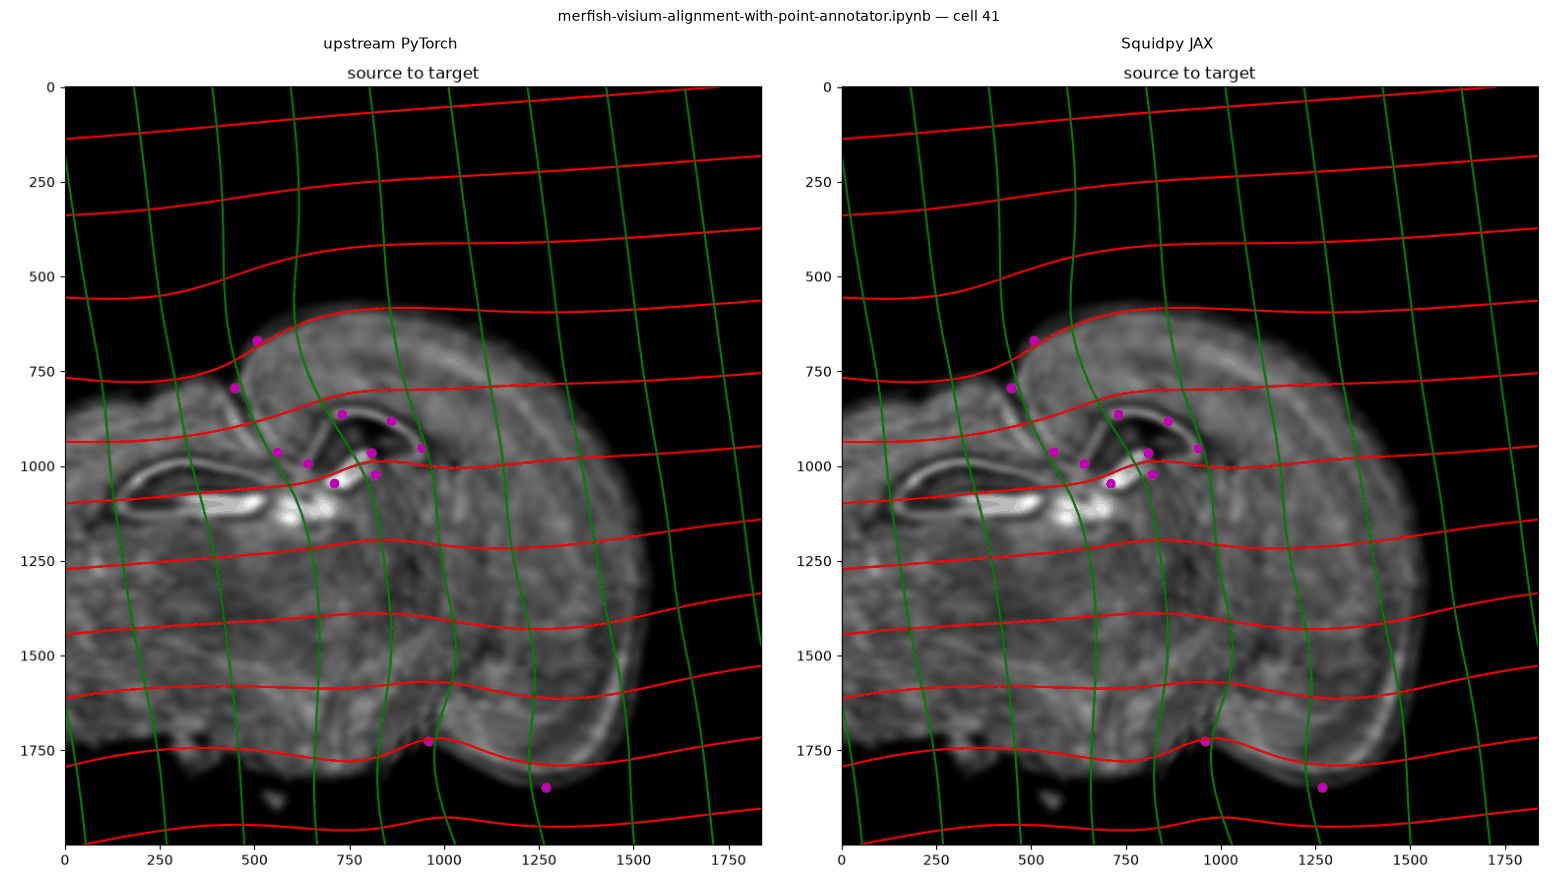

In [9]:
# apply transform
phii = STalign.build_transform(xv,v,A,XJ=[YJ,XJ],direction='b')
phiI = STalign.transform_image_source_to_target(xv,v,A,[YI,XI],I,[YJ,XJ])
phiipointsI = STalign.transform_points_source_to_target(xv,v,A,pointsI)

#switch tensor from cuda to cpu for plotting with numpy
if phii.is_cuda:
    phii = phii.cpu()
if phiI.is_cuda:
    phiI = phiI.cpu()
if phiipointsI.is_cuda:
    phiipointsI = phiipointsI.cpu()


# plot with grids
fig,ax = plt.subplots()
levels = np.arange(-100000,100000,1000)

ax.contour(XJ,YJ,phii[...,0],colors='r',linestyles='-',levels=levels)
ax.contour(XJ,YJ,phii[...,1],colors='g',linestyles='-',levels=levels)
ax.set_aspect('equal')
ax.set_title('source to target')

ax.imshow(phiI.permute(1,2,0)/torch.max(phiI),extent=extentJ)
ax.scatter(phiipointsI[:,1].detach(),phiipointsI[:,0].detach(),c="m")

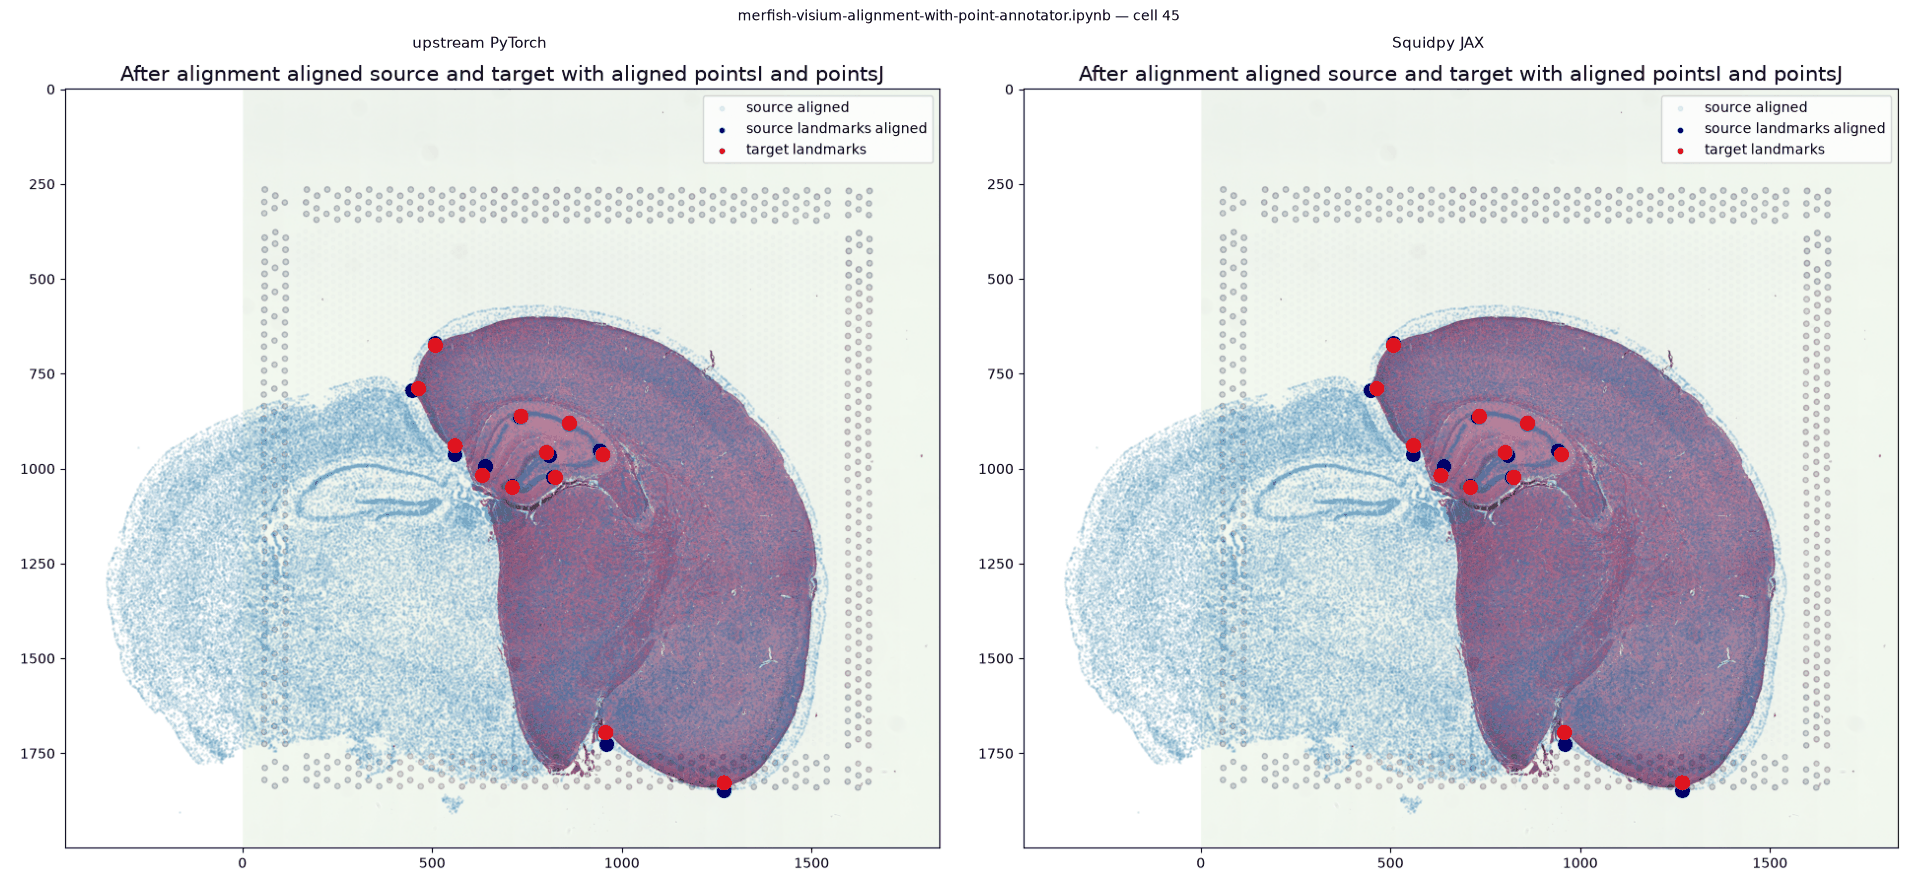

In [10]:
# plot results
fig,ax = plt.subplots()

ax.imshow((J).transpose(1,2,0),extent=extentJ)

ax.scatter(xI_LDDMM,yI_LDDMM,s=1,alpha=0.1, label = 'source aligned')
ax.scatter(phiipointsI[:,1].detach(),phiipointsI[:,0].detach(),c="blue", label='source landmarks aligned', s=100)
    
ax.scatter(pointsJ[:,1],pointsJ[:,0], c='red', label='target landmarks', s=100)
ax.set_aspect('equal')

lgnd = plt.legend(loc="upper right", scatterpoints=1, fontsize=10)
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])
    
ax.set_title('After alignment aligned source and target with aligned pointsI and pointsJ', fontsize=15)

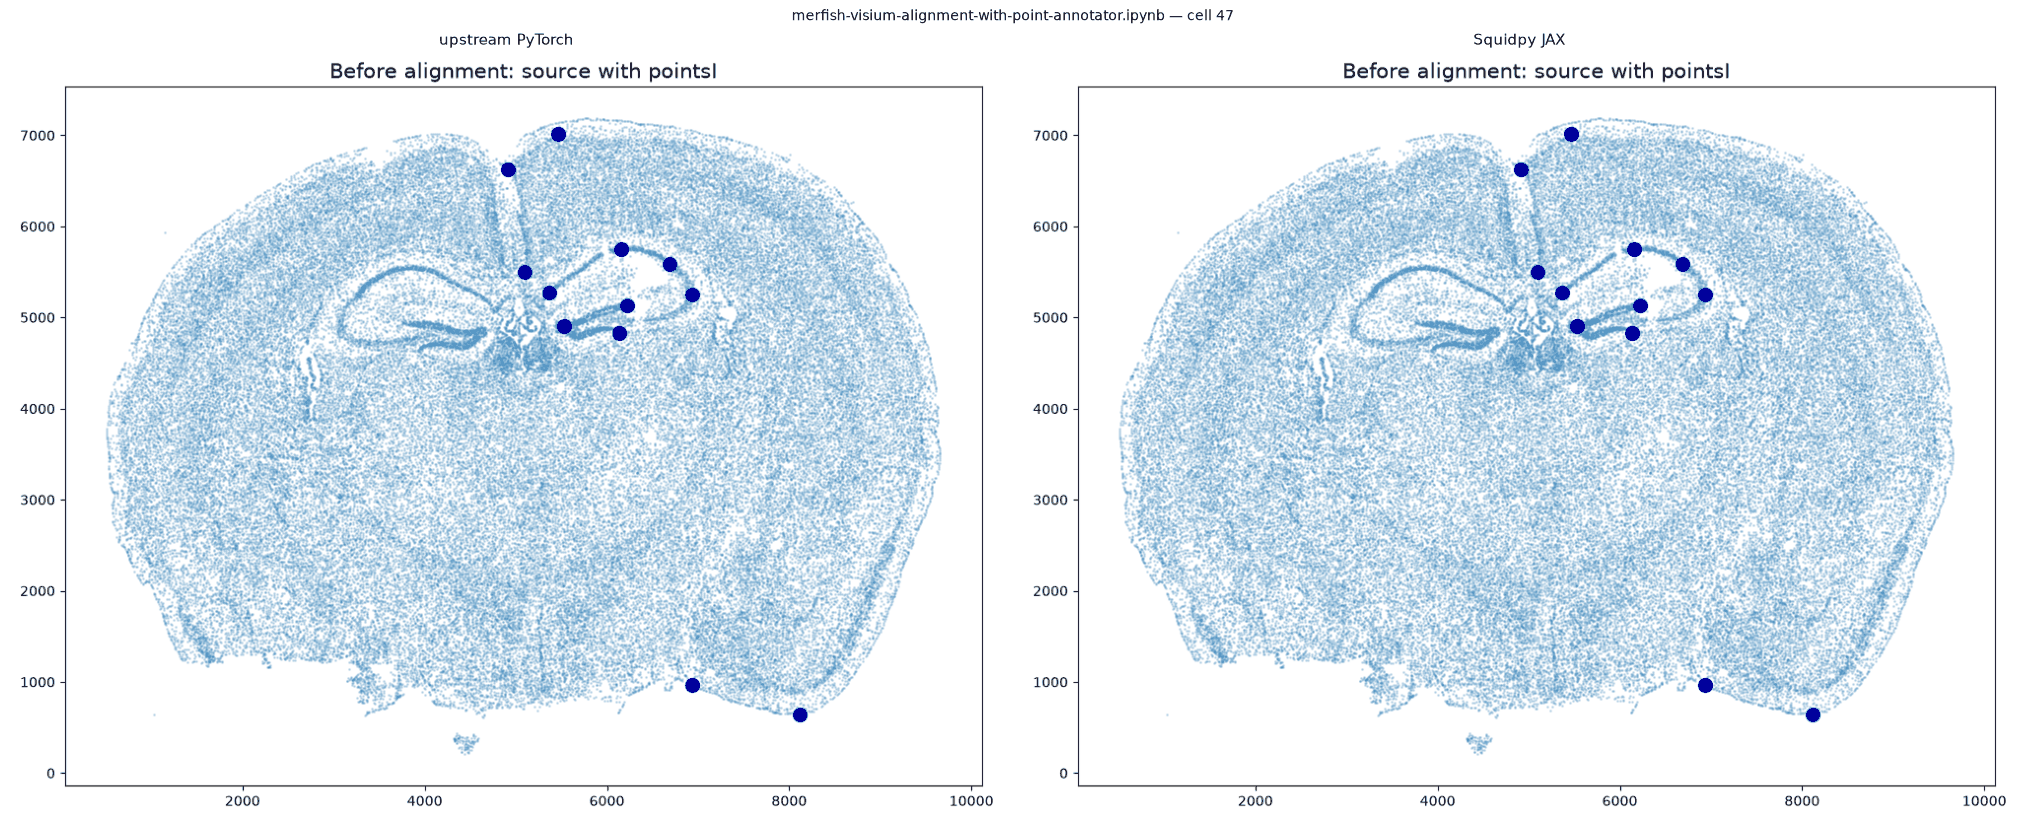

In [11]:
# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2)
ax.set_aspect('equal', 'box')
ax.scatter(pointsI[:,1],pointsI[:,0], c='blue', s=100)
ax.set_title('Before alignment: source with pointsI', fontsize=15)

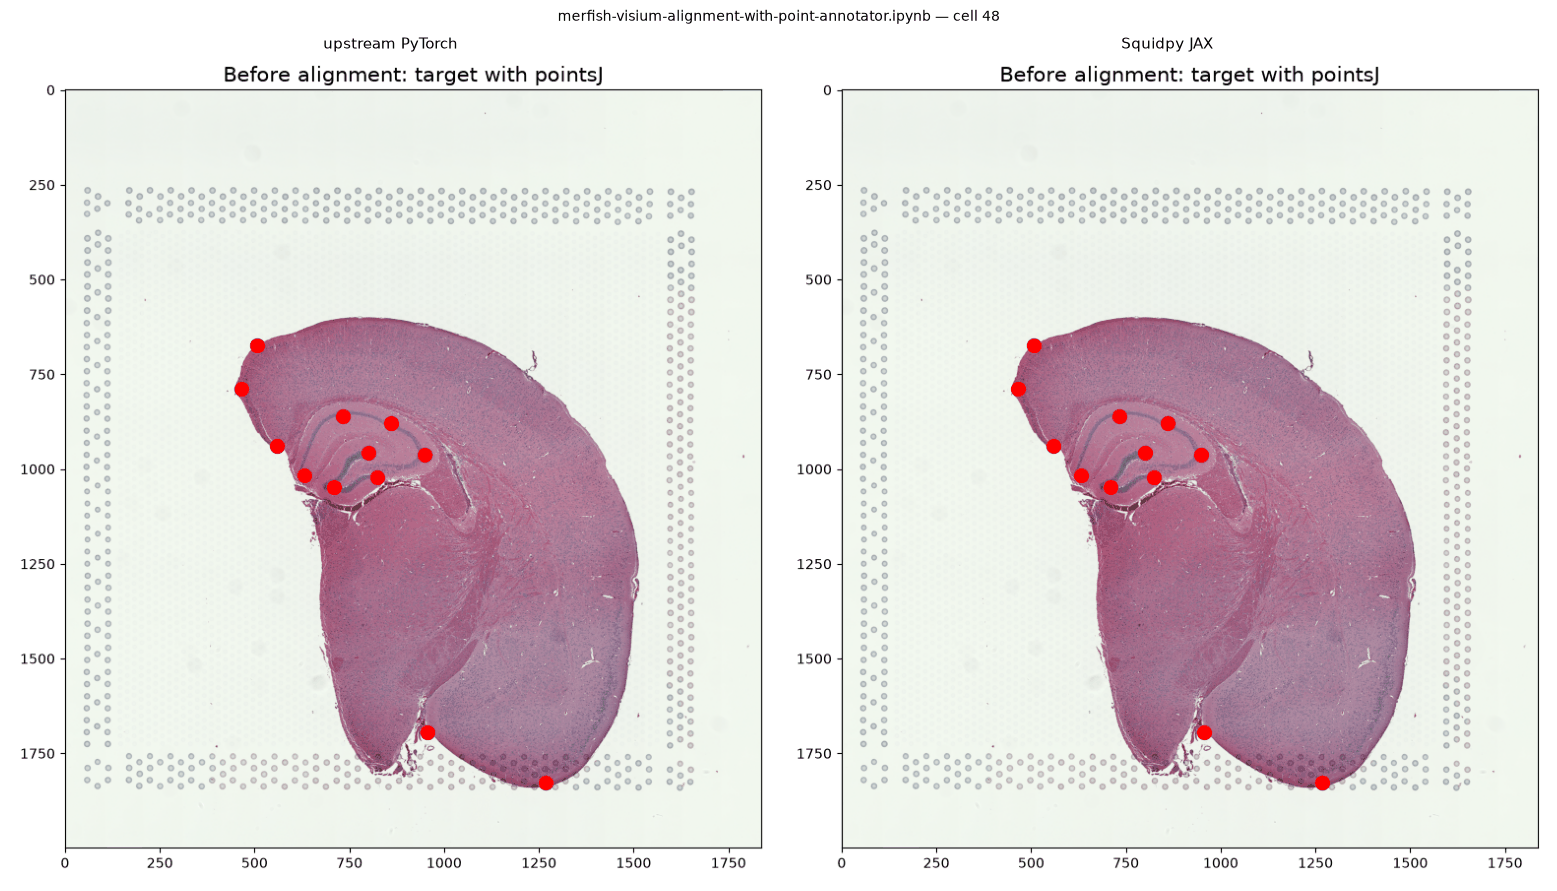

In [12]:
fig,ax = plt.subplots()
ax.imshow((J.transpose(1,2,0).squeeze()), extent=extentJ)
ax.scatter(pointsJ[:,1],pointsJ[:,0], c='red', s=100)
ax.set_title('Before alignment: target with pointsJ', fontsize=15)

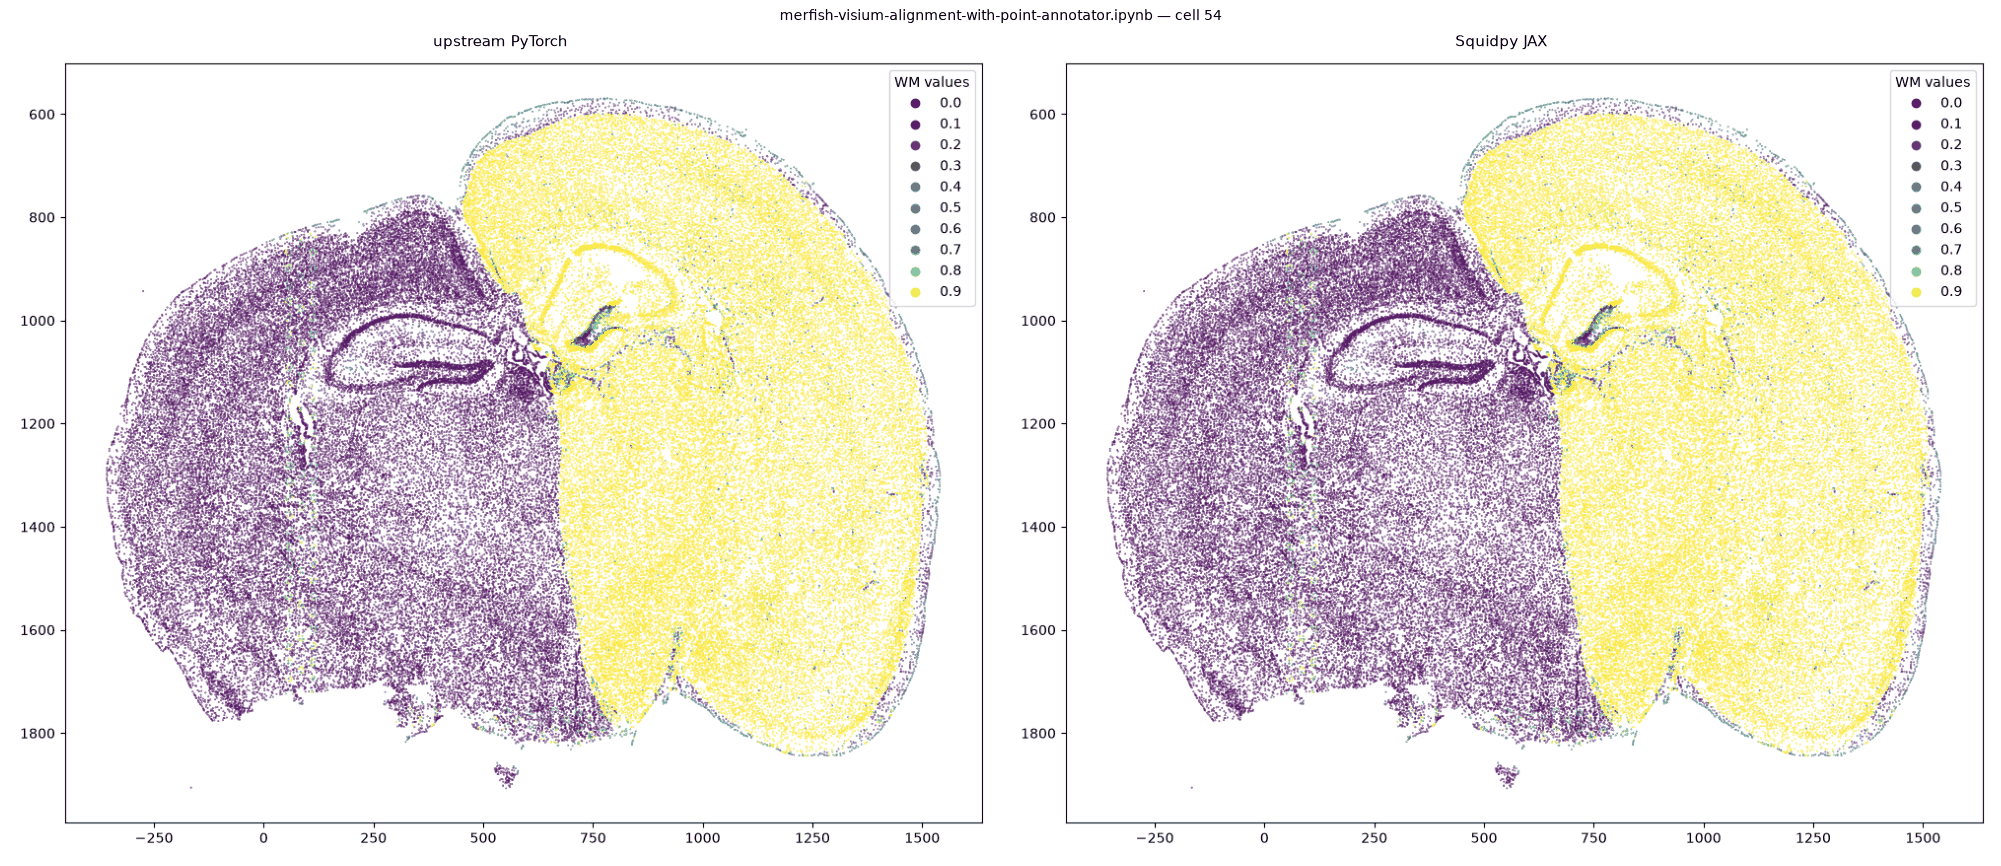

In [13]:
# compute weight values for transformed source points from target image pixel locations and weight 2D array (matching) 
testM = STalign.interp([YJ,XJ],WM[None].float(),tpointsI[None].permute(-1,0,1).float())

#switch tensor from cuda to cpu for plotting with numpy
if testM.is_cuda:
    testM = testM.cpu()

fig,ax = plt.subplots()
scatter = ax.scatter(tpointsI[:,1],tpointsI[:,0],c=testM[0,0],s=0.1,vmin=0,vmax=1, label='WM values')
legend1 = ax.legend(*scatter.legend_elements(),
                    loc="upper right", title="WM values")
ax.invert_yaxis()

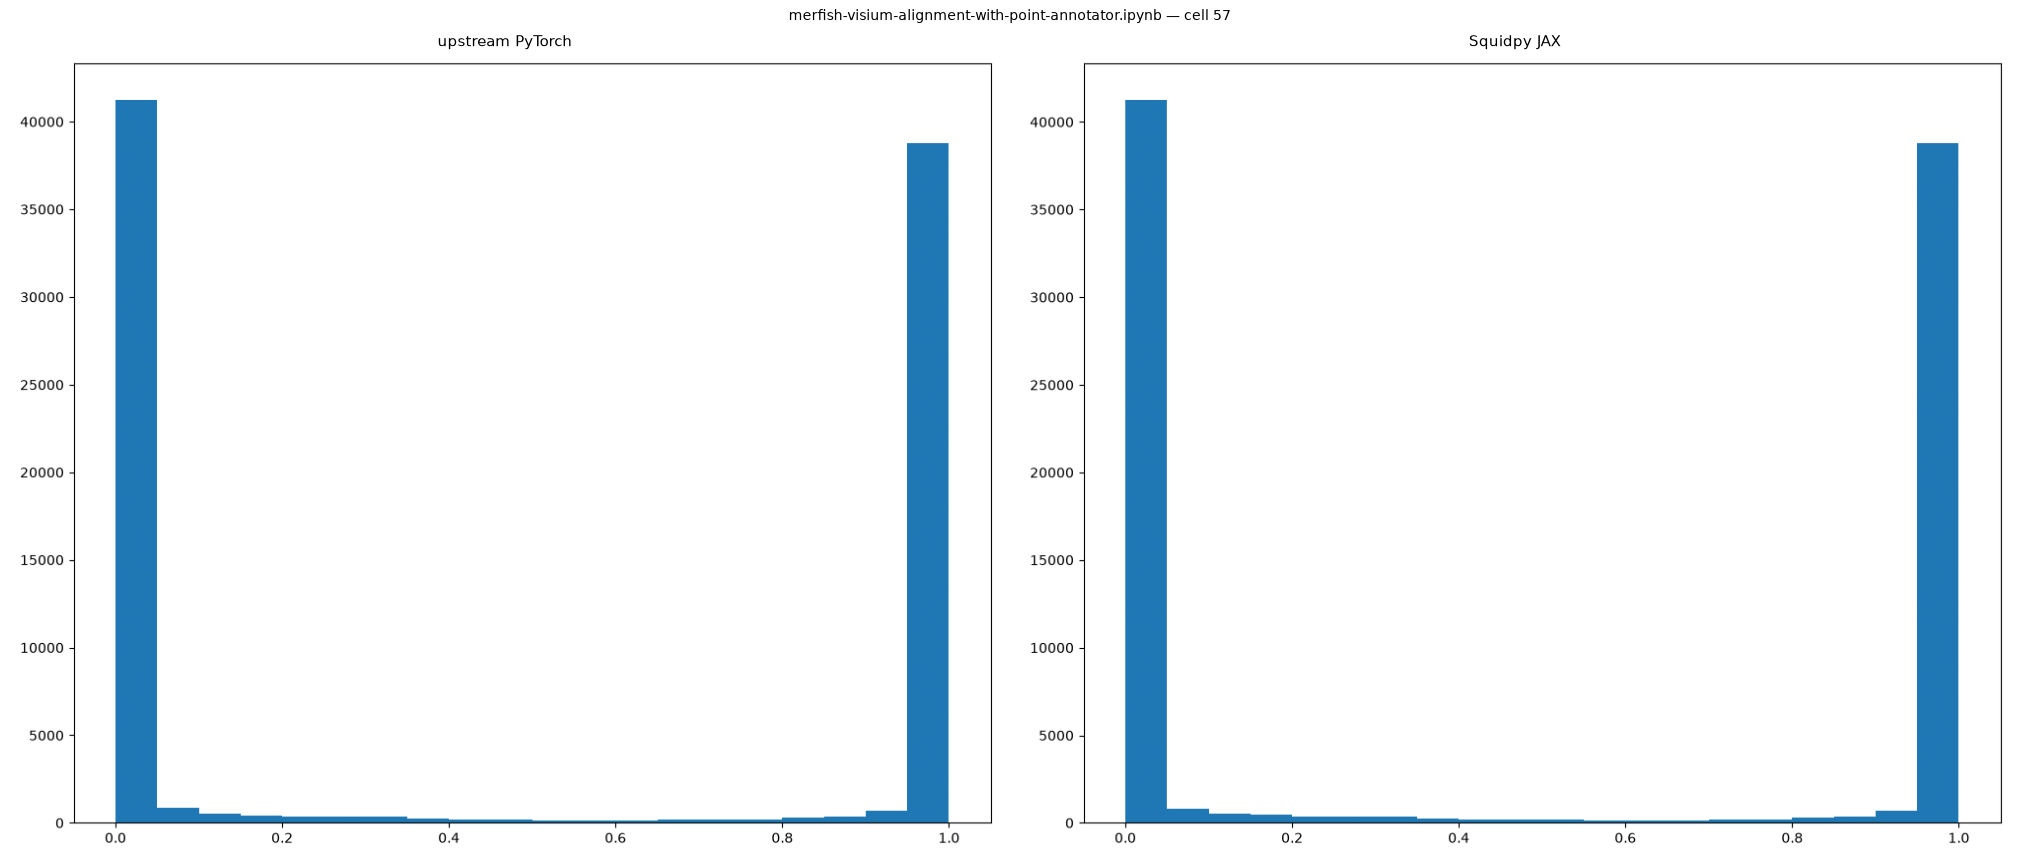

In [14]:
fig,ax = plt.subplots()
ax.hist(results['WM_values'], bins = 20)

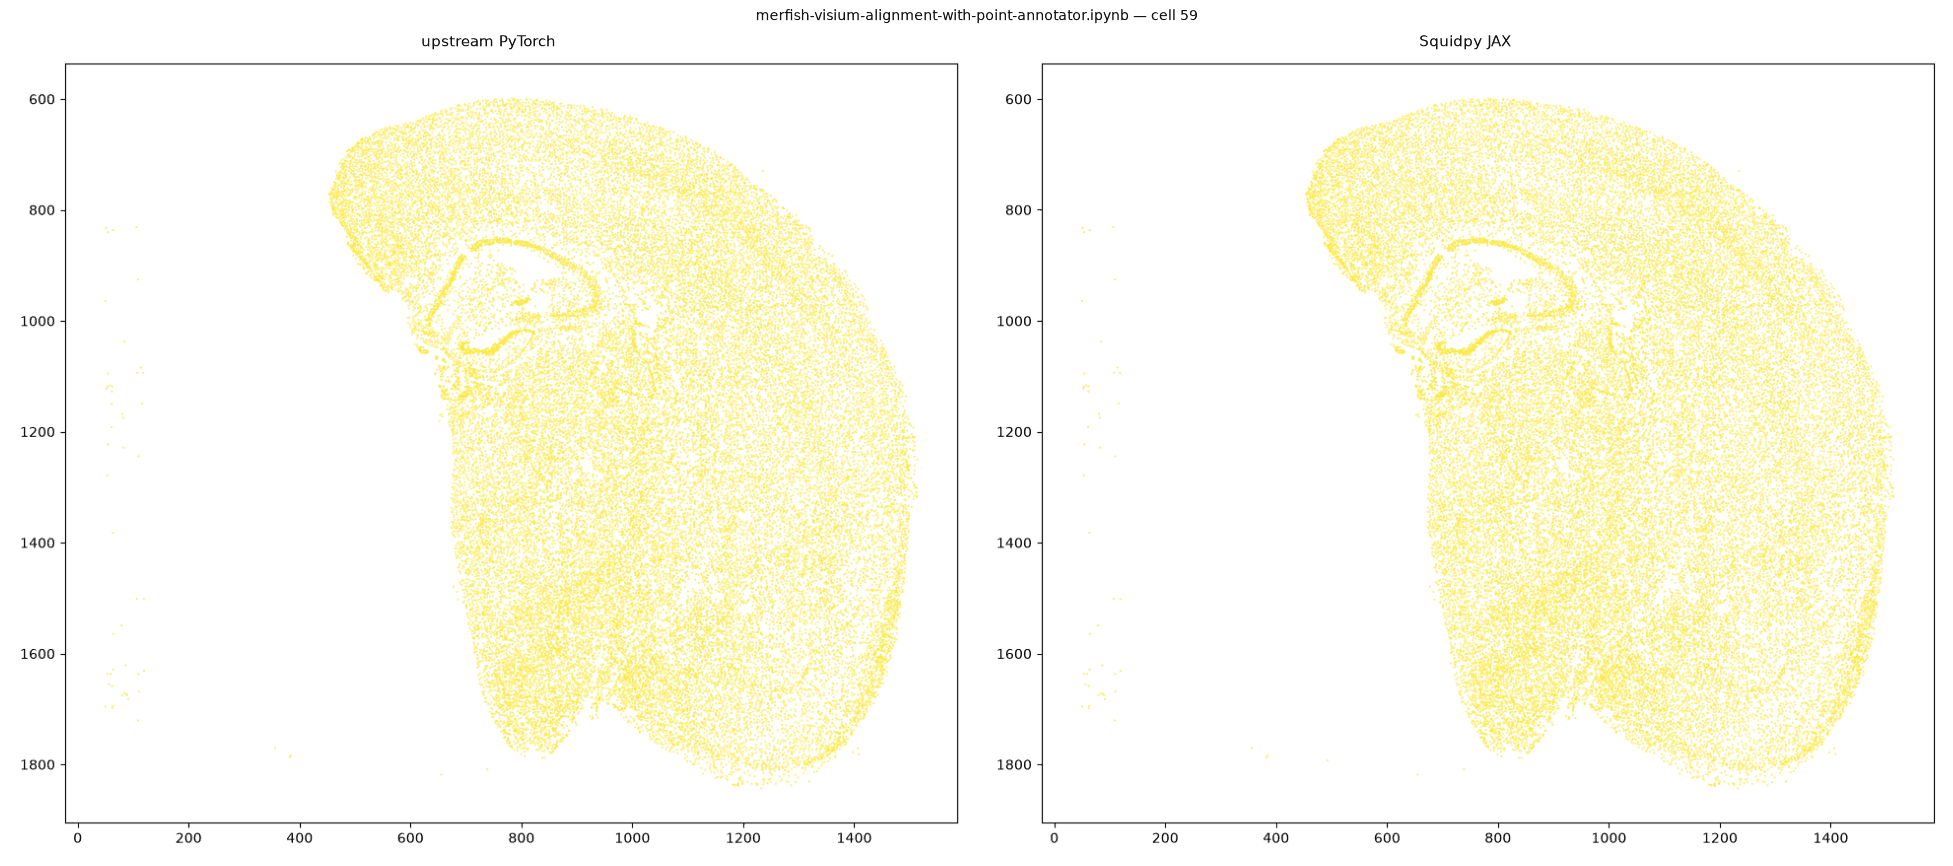

In [15]:
# set a threshold value
WMthresh = .95

# filter transformed MERFISH data
results_filtered = results[results['WM_values'] > WMthresh]

# plot
fig,ax = plt.subplots()
ax.scatter(results_filtered['aligned_x'],results_filtered['aligned_y'],c=results_filtered['WM_values'],s=0.1,vmin=0,vmax=1)
ax.set_aspect('equal')
ax.invert_yaxis()
plt.show()